In [60]:
import os
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit
from scipy.stats import gaussian_kde

import pymc as pm
import arviz as az
import pytensor.tensor as pt

## Helpers

In [32]:
def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)


def load_population(csv_path: Path, keep_rows: int = 20) -> tuple[np.ndarray, np.ndarray]:
    """
    Load population CSV and return:
      - raw counts matrix (20 x 2) for [male, female]
      - percentage matrix summing to 100 across all 40 cells
    Mirrors the R behavior: take columns 2 and 3, drop "100+" tail if present.
    """
    df = pd.read_csv(csv_path)
    try:
        arr = df.iloc[:, [1, 2]].to_numpy()
    except Exception:
        num = df.select_dtypes(include=[np.number])
        if num.shape[1] < 2:
            raise ValueError(f"Expected at least two numeric columns in {csv_path}")
        arr = num.iloc[:, :2].to_numpy()

    # Keep first 20 rows (trim 100+ if present), pad with zeros if fewer
    if arr.shape[0] >= keep_rows:
        arr = arr[:keep_rows, :]
    else:
        pad = np.zeros((keep_rows - arr.shape[0], arr.shape[1]))
        arr = np.vstack([arr, pad])

    raw = arr.astype(float)
    perc = (raw / raw.sum()) * 100.0
    return raw, perc, df


def load_house_data(data_dir: Path) -> pd.DataFrame:
    """
    Load adult and children datasets used in House et al., 2020 example.
    Returns combined DataFrame with columns:
      ['SUBJECT_ID','GENDER_1female','fieldid','AGE_in_years','choice','gender']
    where gender is encoded as 1=male, 2=female (R parity).
    """
    df_adult = pd.read_csv(data_dir / "Model_1a_1b_1c_data.csv")
    df_adult = df_adult[["SUBJECT_ID", "GENDER_1female", "fieldid", "AGE_in_years", "T1_ad_choice_1yes"]].copy()
    df_adult["choice"] = df_adult["T1_ad_choice_1yes"]
    df_adult = df_adult.drop(columns=["T1_ad_choice_1yes"])

    df_children = pd.read_csv(data_dir / "Model_4a_4b_4c_4d_data.csv")
    df_children = df_children[["SUBJECT_ID", "GENDER_1female", "fieldid", "AGE_in_years", "T1_choice_1yes"]].copy()
    df_children["choice"] = df_children["T1_choice_1yes"]
    df_children = df_children.drop(columns=["T1_choice_1yes"])

    df_comb = pd.concat([df_children, df_adult], ignore_index=True)
    df_comb = df_comb.sort_values(by=["fieldid", "AGE_in_years"]).reset_index(drop=True)
    # R: data_comb$gender <- data_comb$GENDER_1female + 1  (1=male, 2=female)
    df_comb["gender"] = df_comb["GENDER_1female"].astype(int) + 1
    return comb


def bin_ages_to_5yr(age_series: pd.Series, max_age: int = 100) -> np.ndarray:
    """
    Bin ages into 20 bins of width 5: [1-5], [6-10], ..., [96-100].
    Return 1-based bin indices (1..20) to match the R script.
    """
    ages = age_series.to_numpy().astype(float)
    ages = np.clip(ages, 1, max_age)
    edges = np.arange(0, max_age + 5, 5)  # 0,5,10,...,100
    bins = np.digitize(ages, edges, right=True)
    bins = np.clip(bins, 1, 20)
    return bins.astype(int)


def sample_pyramid_counts(df: pd.DataFrame, age_binned_col: str = "AGE_binned") -> np.ndarray:
    """
    Build 20x2 matrix of counts by age bin (rows) and gender (cols: 1=male, 2=female).
    """
    M = np.zeros((20, 2), dtype=int)
    for i in range(1, 21):
        for g in (1, 2):
            M[i - 1, g - 1] = int(((df[age_binned_col] == i) & (df["gender"] == g)).sum())
    df_m=pd.DataFrame(data=M, columns=(0,1), index=list(range(1, 21)))
    return M, df_m

In [21]:
#plotting
def _kde_fill(ax, samples, xs):
    kde = gaussian_kde(samples)
    ys = kde(xs)
    ax.plot(xs, ys)
    ax.fill_between(xs, 0, ys, alpha=0.4)


def pyramid_plot(ax, left_vals: np.ndarray, right_vals: np.ndarray, title: str, xlim: float, xlabel: str | None = None):
    """
    Simple population pyramid: left bars extend leftwards (males), right bars extend rightwards (females).
    left_vals, right_vals: length-20 arrays (percentages or counts).
    """
    y = np.arange(20)  # 0..19 (top=youngest, to mimic R order)
    ax.barh(y, -left_vals, align="center")
    ax.barh(y, right_vals, align="center")
    ax.set_yticks(y)
    labels = []
    for i in range(20):
        lo = i * 5 + 1
        hi = (i + 1) * 5
        labels.append(f"{lo}-{hi}" if i % 2 == 0 else "")
    ax.set_yticklabels(labels)
    ax.set_xlim(-xlim, xlim)
    ax.set_title(title)
    ax.axvline(0, linewidth=0.8)
    if xlabel:
        ax.set_xlabel(xlabel)


def plot_age_curves_pymc(idata_berlin, idata_vanuatu, d_list_berlin: dict, d_list_vanuatu: dict, outdir: Path | None = None):
    """
    Two panels with age- and gender-specific estimates with 89% intervals.
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, idata, dlist, title in [
        (axes[0], idata_berlin, d_list_berlin, "Berlin (Germany)"),
        (axes[1], idata_vanuatu, d_list_vanuatu, "Tanna (Vanuatu)"),
    ]:
        # quantiles for each gender
        pm_m = idata.posterior["pred_p_m"].values  # (chain, draw, MA)
        pm_f = idata.posterior["pred_p_f"].values
        q_m = np.quantile(pm_m.reshape(-1, pm_m.shape[-1]), [0.055, 0.5, 0.945], axis=0)
        q_f = np.quantile(pm_f.reshape(-1, pm_f.shape[-1]), [0.055, 0.5, 0.945], axis=0)

        ages = np.arange(1, 21)
        obs_m = np.isin(ages, np.unique(dlist["age"][dlist["gender"] == 1]))
        obs_f = np.isin(ages, np.unique(dlist["age"][dlist["gender"] == 2]))

        # Plot observed and unobserved separately to control alpha
        for k, (q, dx, obs_mask, marker, label) in enumerate([
            (q_m, -0.25, obs_m, "o", "Male"),
            (q_f, +0.25, obs_f, "^", "Female"),
        ]):
            x_obs = ages[obs_mask] + dx
            x_un  = ages[~obs_mask] + dx
            med, lo, hi = q[1], q[0], q[2]

            # observed
            ax.errorbar(x_obs, med[obs_mask], yerr=[med[obs_mask]-lo[obs_mask], hi[obs_mask]-med[obs_mask]],
                        fmt=marker, alpha=1.0, label=label if k==0 else None)
            # unobserved
            ax.errorbar(x_un, med[~obs_mask], yerr=[med[~obs_mask]-lo[~obs_mask], hi[~obs_mask]-med[~obs_mask]],
                        fmt=marker, alpha=0.2)

        ax.set_title(title)
        ax.set_xlim(0.5, 20.5)
        ax.set_ylim(0.0, 1.0)
        ax.set_xlabel("Age category")
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("Probability of choosing prosocial option")
    axes[1].legend(loc="upper left")
    fig.tight_layout()
    if outdir is not None:
        ensure_dir(outdir)
        fig.savefig(outdir / "age_gender_curves_pymc.png", dpi=200)
    return fig


def plot_demographic_standardization_pymc(
    pop_vanuatu_perc, pop_berlin_perc,
    sample_vanuatu_counts, sample_berlin_counts,
    idata_vanuatu, idata_berlin, idata_vanuatu_emp, idata_berlin_emp,
    outdir: Path | None = None
):
    """
    3x2 layout:
      Row 1: Population pyramids (Vanuatu, Berlin)
      Row 2: Sample pyramids (Vanuatu, Berlin)
      Row 3: Densities (Vanuatu, Berlin)
    """
    fig, axes = plt.subplots(3, 2, figsize=(8.5, 10))
    # Row 1: population pyramids (percent)
    pyramid_plot(
        axes[0, 0],
        left_vals=pop_vanuatu_perc[:, 0],
        right_vals=pop_vanuatu_perc[:, 1],
        title="Tanna (Vanuatu) — Population",
        xlim=10,
        xlabel=None
    )
    axes[0, 0].set_ylabel("Age class")
    pyramid_plot(
        axes[0, 1],
        left_vals=pop_berlin_perc[:, 0],
        right_vals=pop_berlin_perc[:, 1],
        title="Berlin (Germany) — Population",
        xlim=10,
        xlabel="Share of population per age class and gender [%]"
    )

    # Row 2: sample pyramids (counts)
    pyramid_plot(
        axes[1, 0],
        left_vals=sample_vanuatu_counts[:, 0],
        right_vals=sample_vanuatu_counts[:, 1],
        title="Tanna (Vanuatu) — Sample",
        xlim=max(1, float(np.ceil(sample_vanuatu_counts.max() / 5) * 5)),
        xlabel=None
    )
    axes[1, 0].set_ylabel("Age class")
    pyramid_plot(
        axes[1, 1],
        left_vals=sample_berlin_counts[:, 0],
        right_vals=sample_berlin_counts[:, 1],
        title="Berlin (Germany) — Sample",
        xlim=max(1, float(np.ceil(sample_berlin_counts.max() / 5) * 5)),
        xlabel="Number of individuals per age class and gender"
    )

    # Row 3: posterior densities (empirical vs poststratified to pop & other)
    # Vanuatu
    ax = axes[2, 0]
    p_emp_van = idata_vanuatu_emp.posterior["p_prob"].values.reshape(-1)
    p_pop_van = idata_vanuatu.posterior["p_pop"].values.reshape(-1)
    p_other_van = idata_vanuatu.posterior["p_other"].values.reshape(-1)
    xs = np.linspace(0.0, 1.0, 500)
    for arr in [p_emp_van, p_pop_van, p_other_van]:
        _kde_fill(ax, arr, xs)
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)
    ax.set_ylabel("Density")
    ax.legend(["Empirical estimate", "Poststratified to sample population", "Poststratified to other population"], loc="upper left")

    # Berlin
    ax = axes[2, 1]
    p_emp_ber = idata_berlin_emp.posterior["p_prob"].values.reshape(-1)
    p_pop_ber = idata_berlin.posterior["p_pop"].values.reshape(-1)
    p_other_ber = idata_berlin.posterior["p_other"].values.reshape(-1)
    for arr in [p_emp_ber, p_pop_ber, p_other_ber]:
        _kde_fill(ax, arr, xs)
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Probability of choosing prosocial option")

    fig.tight_layout()
    if outdir is not None:
        ensure_dir(outdir)
        fig.savefig(outdir / "demographic_standardization_pymc.png", dpi=200)
    return fig

## Load data

In [22]:
data_dir = Path('data')
outdir = Path('outputs')

# Load population distributions
pop_ber_raw, pop_ber_perc, df_pop_ber = load_population(data_dir / "Berlin-2020.csv")
pop_van_raw, pop_van_perc, df_van_ber = load_population(data_dir / "Vanuatu-2019.csv")

In [23]:
df_pop_ber

,Age,Male,Female
0,unter 5,99098,93990
1,5 bis unter 10,85936,81468
2,10 bis unter 15,78123,73553
3,15 bis unter 20,75952,71474
4,20 bis unter 25,99848,100204
5,25 bis unter 30,143314,145141
6,30 bis unter 35,165499,160660
7,35 bis unter 40,146101,139593
8,40 bis unter 45,118256,112626
9,45 bis unter 50,117064,111891


In [17]:
# Load subject-level data and split by site
df_data_comb = load_house_data(data_dir)
# Extract Berlin (fieldid==1) and Tanna, Vanuatu (fieldid==7)
df_berlin = df_data_comb.loc[df_data_comb["fieldid"] == 1].copy()
df_vanuatu = df_data_comb.loc[df_data_comb["fieldid"] == 7].copy()

In [33]:
# Bin ages into 20 five-year bins (1..20)
df_berlin["AGE_binned"] = bin_ages_to_5yr(df_berlin["AGE_in_years"])
df_vanuatu["AGE_binned"] = bin_ages_to_5yr(df_vanuatu["AGE_in_years"])

# Sample pyramids (20x2)
sample_berlin, df_sample_berlin = sample_pyramid_counts(df_berlin)
sample_vanuatu, df_sample_vanuatu = sample_pyramid_counts(df_vanuatu)

## Models

In [38]:
def fit_mrp_gp(
        age, gender, outcome,                 # arrays length N
        P_Pop, P_other,                       # shape (2, MA), ints or floats
        MA,                                   # number of age bins (e.g., 20)
        draws=2500, tune=2500, chains=4, seed=1
    ):
    """
    Gaussian-process MRP with age effects by gender, plus poststratification.

    gender: 1=male, 2=female   (like Stan). Converted internally to 0/1.
    age:    1..MA              (like Stan). Converted internally to 0..MA-1.
    """
    age = np.asarray(age, dtype=int) - 1
    gender = np.asarray(gender, dtype=int) - 1
    outcome = np.asarray(outcome, dtype="int8")
    P_Pop = np.asarray(P_Pop, dtype=float)
    P_other = np.asarray(P_other, dtype=float)

    # Pairwise squared-distance matrix normalized by MA^2 (numpy)
    idx = np.arange(MA)
    D2_np = ((idx[None, :] - idx[:, None]) ** 2).astype(float) / (MA ** 2)
    I_np = np.eye(MA, dtype=float)

    with pm.Model() as m:
        # Priors (same families as Stan)
        alpha = pm.Normal("alpha", mu=0.0, sigma=3.0, shape=2)          # intercept by gender
        eta   = pm.Exponential("eta", lam=2.0, shape=2)                 # GP decay
        sigma = pm.Exponential("sigma", lam=1.0, shape=2)               # GP scale
        rho   = pm.Beta("rho", alpha=10.0, beta=1.0, shape=2)           # off-diagonal multiplier

        D2 = pt.as_tensor_variable(D2_np)
        I = pt.as_tensor_variable(I_np)

        age_effect_rows = []
        for g in range(2):
            # Rho_g: diag=1, off-diag = rho[g] * exp(-eta[g] * D2)
            base = rho[g] * pt.exp(-eta[g] * D2) 
            Rho_g = base * (1.0 - I) + I  # enforce unit diagonal
            L_g = pt.linalg.cholesky(Rho_g)         # Lower cholesky of correlation-like matrix, Rho_g_mean=L_g*L_g.T
            L_scaled = sigma[g] * L_g               # multiply by scale (S) to scale to covariance

            # zero-mean GP over age bins for this gender
            age_eff_g = pm.MvNormal(f"age_effect_g{g}", mu=pt.zeros(MA), chol=L_scaled, shape=MA)
            age_effect_rows.append(age_eff_g)

        age_effect = pt.stack(age_effect_rows, axis=0)  # (2, MA)
        age_effect = pm.Deterministic("age_effect", age_effect)

        # Linear predictor per observation
        lin = alpha[gender] + age_effect[gender, age]

        # Likelihood
        pm.Bernoulli("y", logit_p=lin, observed=outcome)

        # Generated-quantities equivalents
        pred_p_m = pm.Deterministic("pred_p_m", pm.math.sigmoid(alpha[0] + age_effect[0, :]))
        pred_p_f = pm.Deterministic("pred_p_f", pm.math.sigmoid(alpha[1] + age_effect[1, :]))

        p_age_gender = pm.math.sigmoid(alpha[:, None] + age_effect)  # (2, MA)
        P_Pop_t   = pt.as_tensor_variable(P_Pop)
        P_other_t = pt.as_tensor_variable(P_other)

        p_pop = pm.Deterministic("p_pop", (P_Pop_t * p_age_gender).sum() / P_Pop_t.sum())
        p_other = pm.Deterministic("p_other", (P_other_t * p_age_gender).sum() / P_other_t.sum())

        idata = pm.sample(
            draws=draws, tune=tune, chains=chains, random_seed=seed,
            target_accept=0.99, max_treedepth=13
        )
    return idata

In [42]:
def fit_empirical(outcome, draws=2500, tune=2500, chains=4, seed=1):
    """
    Empirical Bernoulli-logit model with a single logit parameter p.
    Stan had no explicit prior; we use a very weak Normal(0, 10).
    """
    outcome = np.asarray(outcome, dtype="int8")
    with pm.Model() as m:
        p = pm.Normal("p", mu=0.0, sigma=10.0)
        pm.Bernoulli("y", logit_p=p, observed=outcome)
        pm.Deterministic("p_prob", pm.math.sigmoid(p))  # inv_logit(p)
        idata = pm.sample(
            draws=draws, tune=tune, chains=chains, random_seed=seed,
            target_accept=0.99, max_treedepth=13
        )
    return idata

## Explore models - run after sampling

<Axes: >

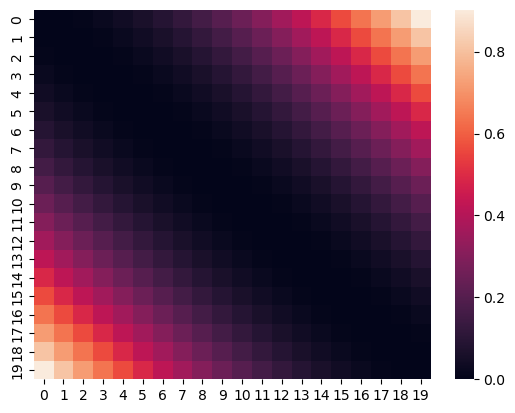

In [63]:
MA=20
idx = np.arange(MA)
D2_np = ((idx[None, :] - idx[:, None]) ** 2).astype(float) / (MA ** 2)
sns.heatmap(D2_np)

In [77]:
# trace_berlin.posterior.eta
D2 = pt.as_tensor_variable(D2_np)
D2

TensorConstant(TensorType(float64, shape=(20, 20)), data=array([[0. ... 0.    ]]))

In [110]:
# Collapse chains & draws to one "sample" dim
rho = trace_berlin.posterior["rho"].stack(sample=("chain","draw"))      # (sample, gender=2)
eta = trace_berlin.posterior["eta"].stack(sample=("chain","draw"))      # (sample, gender=2)
sigma = trace_berlin.posterior["sigma"].stack(sample=("chain","draw"))  

In [111]:
sigma.shape

(2, 10000)

In [150]:
D2 = pt.as_tensor_variable(D2_np)             # (20,20)

g = 0
rho_g = pt.as_tensor_variable(rho.isel(rho_dim_0=g).values)  # (S,)
eta_g = pt.as_tensor_variable(eta.isel(eta_dim_0=g).values)  # (S,)
sigma_g = pt.as_tensor_variable(sigma.isel(sigma_dim_0=g).values)  # (S,)

# rho_3d = rho_g[:, None, None]                 # (S,1,1)
# eta_3d = eta_g[:, None, None]                 # (S,1,1)
# D2_3d  = D2[None, :, :]                       # (1,20,20)

# base = rho_3d * pt.exp(-eta_3d * D2_3d)       # (S,20,20)
# base

In [153]:
#single posterior mean
g=1
rho_g_mean = rho.isel(rho_dim_0=g).mean().item()
eta_g_mean = eta.isel(eta_dim_0=g).mean().item()
base_mean  = rho_g_mean * np.exp(-eta_g_mean * D2_np)   # (20,20)
Rho_g_mean = base_mean * (1.0 - np.eye(MA)) + np.eye(MA)

L_g = pt.linalg.cholesky(Rho_g_mean)         # Lower cholesky of correlation-like matrix
L_scaled = sigma_g[g] * L_g               # multiply by scale (S), scaling to covariance

<Axes: >

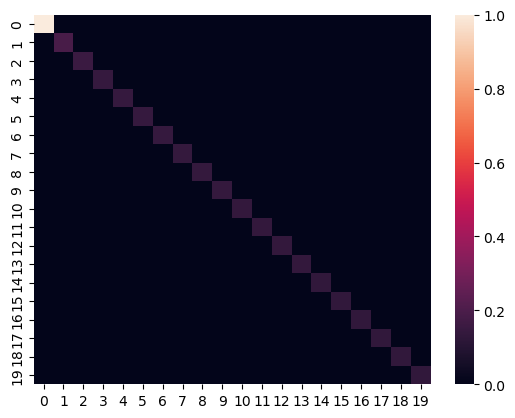

In [139]:
rho_g_mean

0.902138799720793

In [140]:
eta_g_mean

0.8736926416751191

In [146]:
sigma_g.eval()

array([3.21717394, 4.05452409, 3.95301341, ..., 0.41123561, 0.16421626,
       0.07790391], shape=(10000,))

<Axes: >

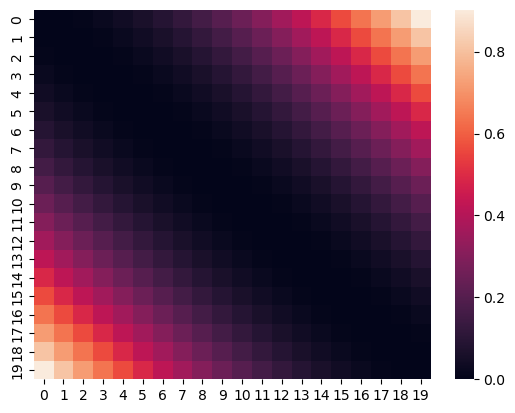

In [148]:
sns.heatmap(D2_np)

<Axes: >

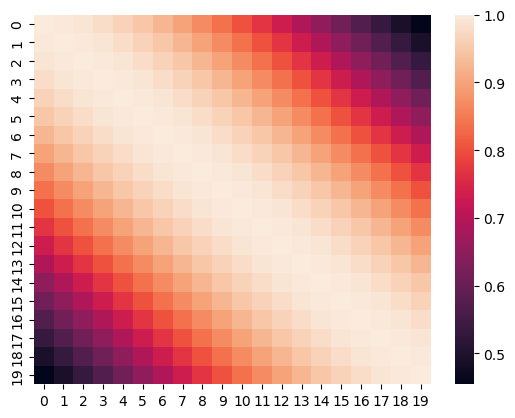

In [149]:
sns.heatmap(np.exp(-eta_g_mean * D2_np))

<Axes: >

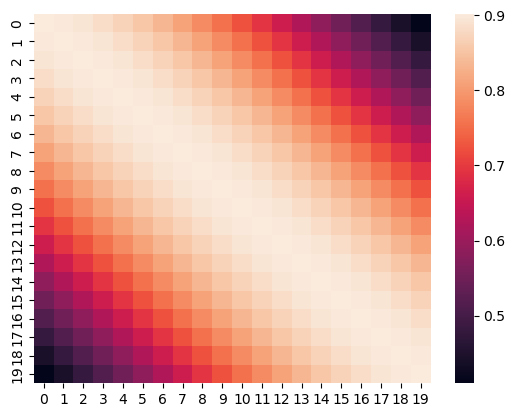

In [141]:
sns.heatmap(base_mean)

<Axes: >

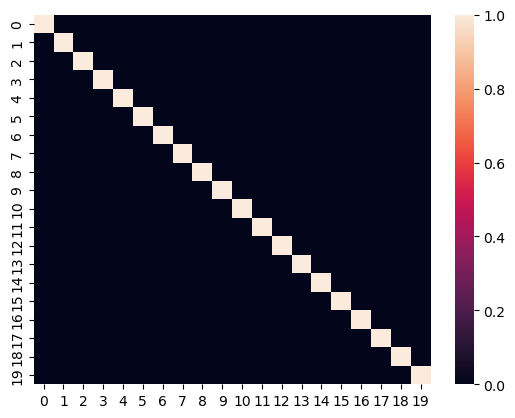

In [107]:
sns.heatmap(np.eye(MA))

<Axes: >

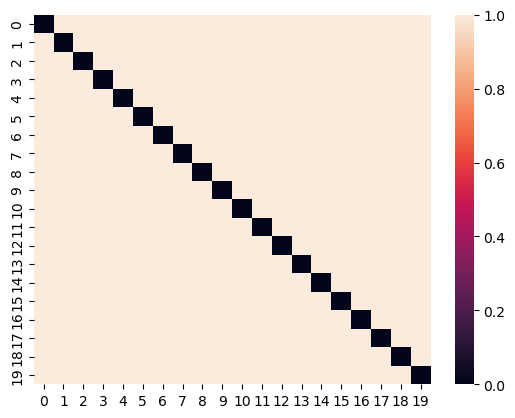

In [108]:
sns.heatmap((1.0 - np.eye(MA)))

<Axes: >

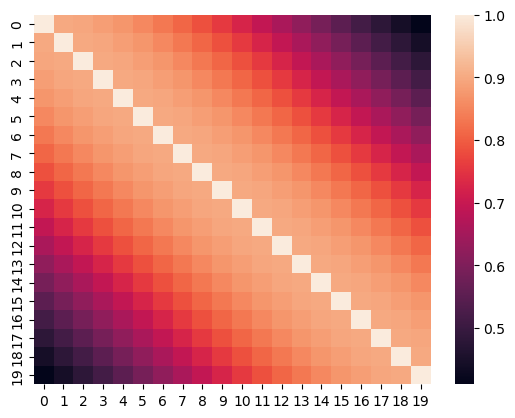

In [142]:
#rho_g_mean = rho.isel(rho_dim_0=g).mean().item()
sns.heatmap(Rho_g_mean)

<Axes: >

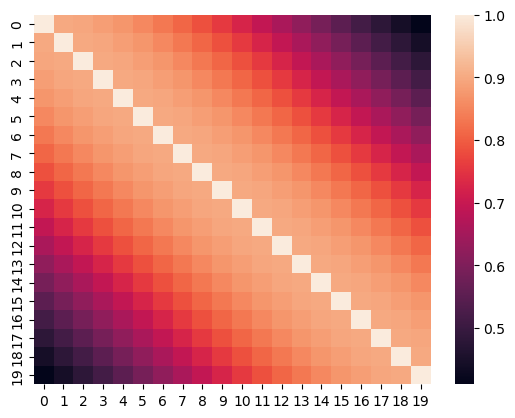

In [161]:
#this is Rho_g_mean
sns.heatmap((L_g@L_g.T).eval())

In [162]:
np.allclose(Rho_g_mean, (L_g@L_g.T).eval(), atol=1e-8)

True

<Axes: >

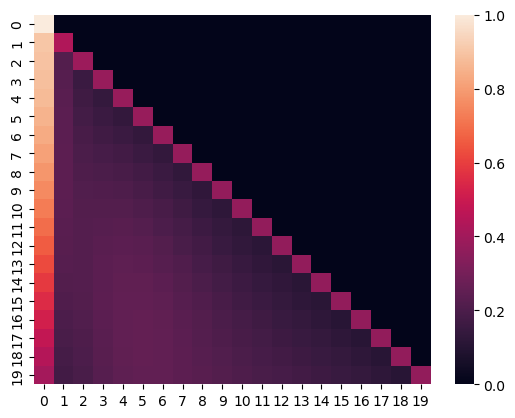

In [132]:
#L_g = pt.linalg.cholesky(Rho_g_mean) 
sns.heatmap(L_g.eval())

(array([1.135e+03, 1.160e+03, 1.104e+03, 1.052e+03, 9.860e+02, 9.400e+02,
        7.830e+02, 6.880e+02, 5.130e+02, 4.370e+02, 3.590e+02, 2.330e+02,
        1.650e+02, 1.220e+02, 7.800e+01, 9.300e+01, 4.700e+01, 2.900e+01,
        1.900e+01, 1.500e+01, 1.500e+01, 1.200e+01, 5.000e+00, 4.000e+00,
        3.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([ 0.02033848,  0.38365471,  0.74697095,  1.11028719,  1.47360342,
         1.83691966,  2.20023589,  2.56355213,  2.92686837,  3.2901846 ,
         3.65350084,  4.01681707,  4.38013331,  4.74344955,  5.10676578,
         5.47008202,  5.83339826,  6.19671449,  6.56003073,  6.92334696,
         7.2866632 ,  7.64997944,  8.01329567,  8.37661191,  8.73992814,
         9.10324438,  9.46656062,  9.82987685, 10.19319309, 10.55650932,
        10.91982556]),
 <BarContainer object of 30 artists>)

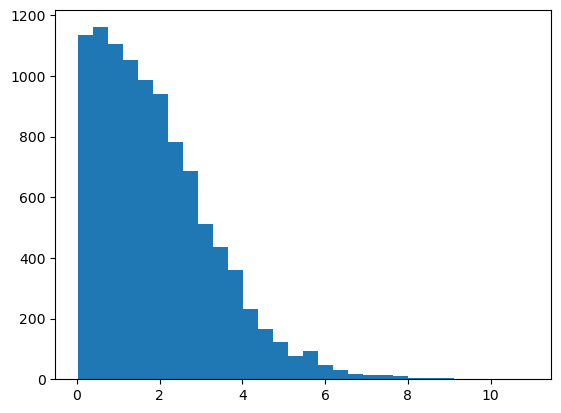

In [129]:
plt.hist(sigma_g.eval(), bins=30)

<Axes: >

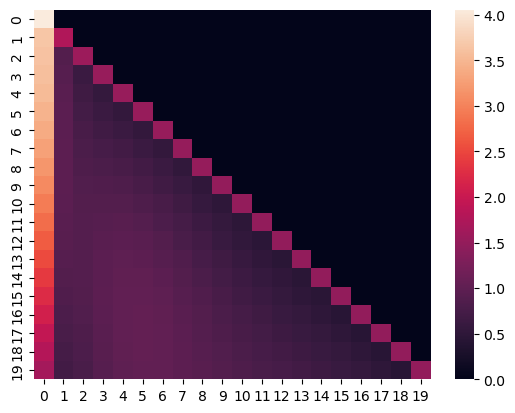

In [135]:
sns.heatmap(L_scaled.eval())

In [165]:
trace_berlin.posterior["p_pop"].shape

(4, 2500)

(array([  1.,   0.,   2.,   9.,  14.,  26.,  63.,  96., 125., 211., 263.,
        394., 555., 657., 769., 842., 952., 930., 878., 841., 695., 576.,
        426., 296., 195.,  99.,  51.,  18.,  11.,   5.]),
 array([0.32380369, 0.34120455, 0.35860541, 0.37600626, 0.39340712,
        0.41080798, 0.42820884, 0.4456097 , 0.46301056, 0.48041141,
        0.49781227, 0.51521313, 0.53261399, 0.55001485, 0.56741571,
        0.58481656, 0.60221742, 0.61961828, 0.63701914, 0.65442   ,
        0.67182085, 0.68922171, 0.70662257, 0.72402343, 0.74142429,
        0.75882515, 0.776226  , 0.79362686, 0.81102772, 0.82842858,
        0.84582944]),
 <BarContainer object of 30 artists>)

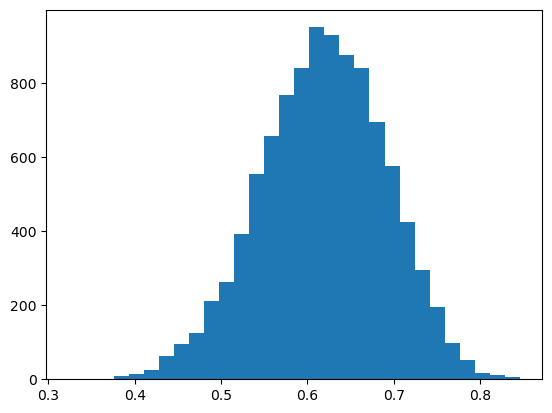

In [170]:
plt.hist(trace_berlin.posterior["p_pop"].values.reshape(-1), bins=30)

(array([1.000e+00, 0.000e+00, 1.000e+00, 9.000e+00, 8.000e+00, 1.300e+01,
        4.300e+01, 8.900e+01, 1.550e+02, 2.450e+02, 3.630e+02, 5.370e+02,
        6.860e+02, 8.430e+02, 9.620e+02, 1.010e+03, 1.019e+03, 9.340e+02,
        8.580e+02, 7.140e+02, 5.400e+02, 3.660e+02, 2.620e+02, 1.570e+02,
        8.900e+01, 4.300e+01, 3.000e+01, 1.600e+01, 4.000e+00, 3.000e+00]),
 array([0.26671611, 0.28309112, 0.29946613, 0.31584114, 0.33221615,
        0.34859116, 0.36496617, 0.38134118, 0.39771619, 0.4140912 ,
        0.43046621, 0.44684123, 0.46321624, 0.47959125, 0.49596626,
        0.51234127, 0.52871628, 0.54509129, 0.5614663 , 0.57784131,
        0.59421632, 0.61059133, 0.62696634, 0.64334135, 0.65971636,
        0.67609137, 0.69246638, 0.7088414 , 0.72521641, 0.74159142,
        0.75796643]),
 <BarContainer object of 30 artists>)

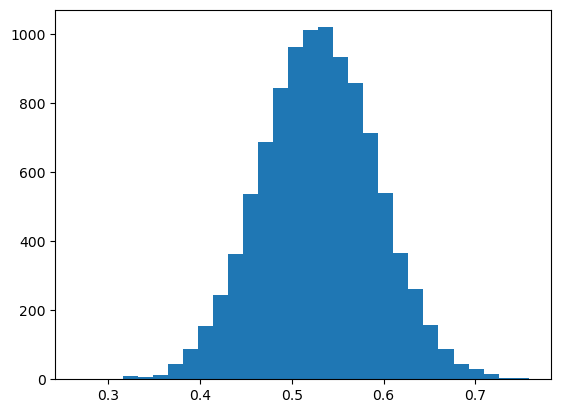

In [171]:
plt.hist(trace_berlin.posterior["p_other"].values.reshape(-1), bins=30)

#### fit models

In [36]:
# Prepare arrays for PyMC
# P_Pop = population of the site being modeled (2, MA); P_other = the other population
MA = 20
d_list_berlin = dict(
    N=len(df_berlin),
    MA=MA,
    age=df_berlin["AGE_binned"].to_numpy().astype(int),
    outcome=df_berlin["choice"].to_numpy().astype(int),
    gender=df_berlin["gender"].to_numpy().astype(int),
    P_Pop=pop_ber_raw.T,
    P_other=pop_van_raw.T,
)

d_list_vanuatu = dict(
    N=len(df_vanuatu),
    MA=MA,
    age=df_vanuatu["AGE_binned"].to_numpy().astype(int),
    outcome=df_vanuatu["choice"].to_numpy().astype(int),
    gender=df_vanuatu["gender"].to_numpy().astype(int),
    P_Pop=pop_van_raw.T,
    P_other=pop_ber_raw.T,
)

In [173]:
d_list_berlin["age"]

array([ 1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  4,
        5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  7,  7,  8,  8,  8,
        8,  8,  9, 10, 11, 11, 11, 11, 12, 12, 13, 14, 15, 15])

In [174]:
d_list_vanuatu["age"]

array([ 2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  5,
        5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,  8,  8,  9,  9,
        9,  9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 12])

In [40]:
draws=2500
tune=2500
chains=4
seed=1

In [41]:
trace_berlin = fit_mrp_gp(
        age=d_list_berlin["age"],
        gender=d_list_berlin["gender"],
        outcome=d_list_berlin["outcome"],
        P_Pop=d_list_berlin["P_Pop"],
        P_other=d_list_berlin["P_other"],
        MA=d_list_berlin["MA"],
        draws=draws, tune=tune, chains=chains, seed=seed
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, eta, sigma, rho, age_effect_g0, age_effect_g1]


Output()

Sampling 4 chains for 2_500 tune and 2_500 draw iterations (10_000 + 10_000 draws total) took 790 seconds.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'age_effect_g0'}>,
        <Axes: title={'center': 'age_effect_g0'}>],
       [<Axes: title={'center': 'age_effect_g1'}>,
        <Axes: title={'center': 'age_effect_g1'}>],
       [<Axes: title={'center': 'eta'}>, <Axes: title={'center': 'eta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'rho'}>, <Axes: title={'center': 'rho'}>],
       [<Axes: title={'center': 'age_effect'}>,
        <Axes: title={'center': 'age_effect'}>],
       [<Axes: title={'center': 'pred_p_m'}>,
        <Axes: title={'center': 'pred_p_m'}>],
       [<Axes: title={'center': 'pred_p_f'}>,
        <Axes: title={'center': 'pred_p_f'}>],
       [<Axes: title={'center': 'p_pop'}>,
        <Axes: title={'center': 'p_pop'}>],
       [<Axes: title={'center': 'p_other'}>,
        <Axes: title={'center': 'p_other'}>]], dtype=ob

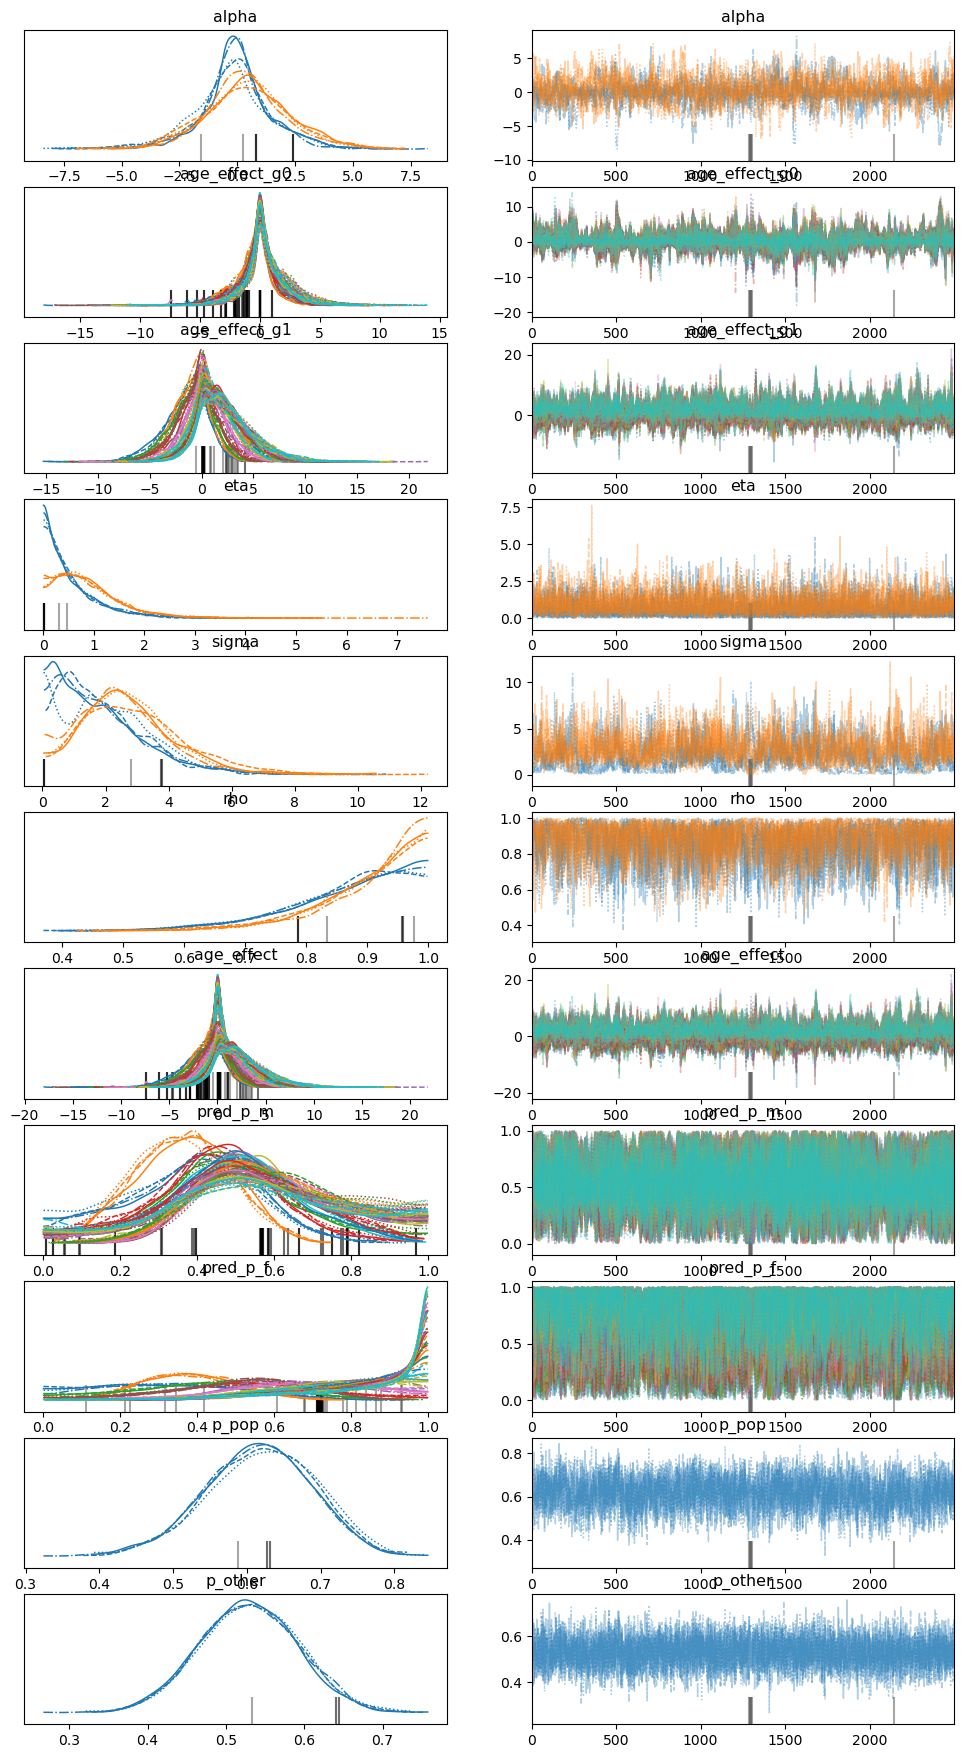

In [45]:
az.plot_trace(trace_berlin)

In [52]:
df_summary_berlin=az.summary(trace_berlin)

In [53]:
df_summary_berlin.sort_values('r_hat', ascending=False)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma[0],1.934,1.420,0.029,4.393,0.119,0.042,105.0,139.0,1.04
age_effect_g0[17],0.449,1.905,-3.052,4.441,0.074,0.095,704.0,774.0,1.03
"age_effect[0, 17]",0.449,1.905,-3.052,4.441,0.074,0.095,704.0,774.0,1.03
alpha[0],-0.122,1.633,-3.281,3.150,0.072,0.077,557.0,596.0,1.02
"age_effect[0, 13]",0.112,1.860,-3.775,3.574,0.082,0.091,563.0,709.0,1.02
...,...,...,...,...,...,...,...,...,...
pred_p_f[15],0.833,0.181,0.488,1.000,0.005,0.003,959.0,1605.0,1.00
pred_p_f[17],0.836,0.186,0.475,1.000,0.005,0.003,966.0,1616.0,1.00
pred_p_f[18],0.836,0.188,0.472,1.000,0.005,0.003,956.0,1720.0,1.00
pred_p_f[19],0.834,0.192,0.462,1.000,0.005,0.003,970.0,1684.0,1.00


In [55]:
df_summary_berlin[df_summary_berlin.r_hat>1.01].shape

(45, 9)

In [43]:
trace_vanuatu = fit_mrp_gp(
    age=d_list_vanuatu["age"],
    gender=d_list_vanuatu["gender"],
    outcome=d_list_vanuatu["outcome"],
    P_Pop=d_list_vanuatu["P_Pop"],
    P_other=d_list_vanuatu["P_other"],
    MA=d_list_vanuatu["MA"],
    draws=draws, tune=tune, chains=chains, seed=seed
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, eta, sigma, rho, age_effect_g0, age_effect_g1]


Output()

Sampling 4 chains for 2_500 tune and 2_500 draw iterations (10_000 + 10_000 draws total) took 2615 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'age_effect_g0'}>,
        <Axes: title={'center': 'age_effect_g0'}>],
       [<Axes: title={'center': 'age_effect_g1'}>,
        <Axes: title={'center': 'age_effect_g1'}>],
       [<Axes: title={'center': 'eta'}>, <Axes: title={'center': 'eta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'rho'}>, <Axes: title={'center': 'rho'}>],
       [<Axes: title={'center': 'age_effect'}>,
        <Axes: title={'center': 'age_effect'}>],
       [<Axes: title={'center': 'pred_p_m'}>,
        <Axes: title={'center': 'pred_p_m'}>],
       [<Axes: title={'center': 'pred_p_f'}>,
        <Axes: title={'center': 'pred_p_f'}>],
       [<Axes: title={'center': 'p_pop'}>,
        <Axes: title={'center': 'p_pop'}>],
       [<Axes: title={'center': 'p_other'}>,
        <Axes: title={'center': 'p_other'}>]], dtype=ob

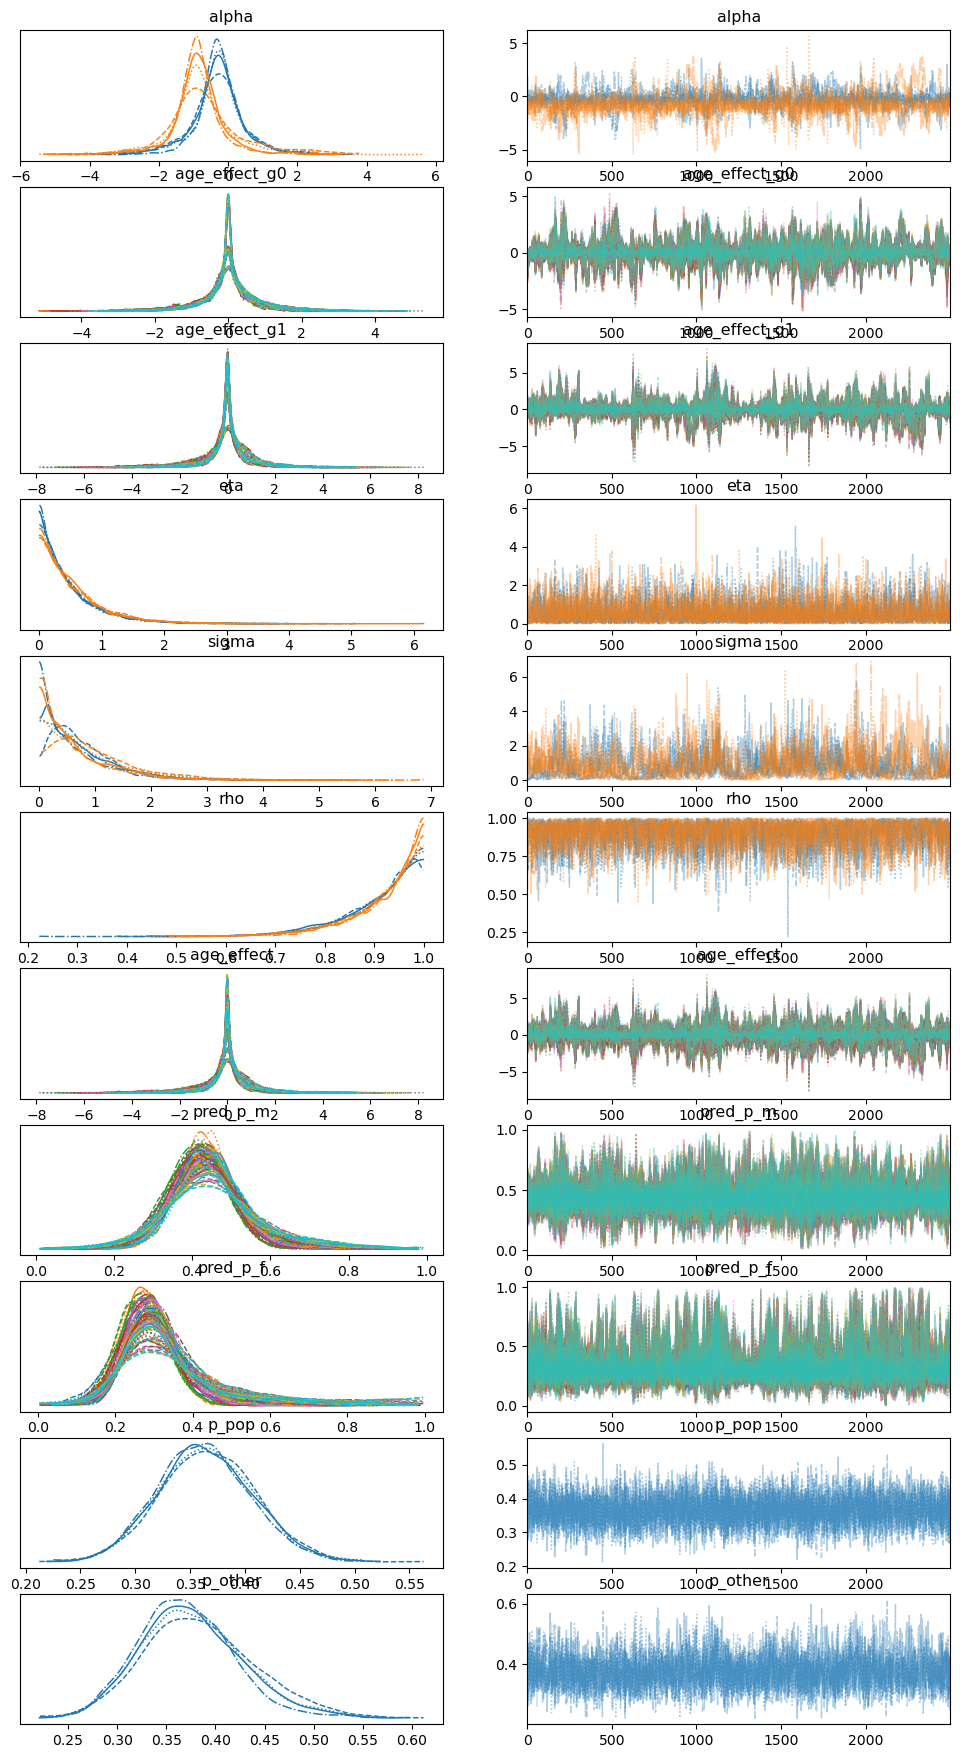

In [47]:
az.plot_trace(trace_vanuatu)

In [50]:
df_summary_vanuatu=az.summary(trace_vanuatu)
df_summary_vanuatu.shape

(130, 9)

In [49]:
df_summary_vanuatu.sort_values('r_hat', ascending=False)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma[0],0.729,0.649,0.004,1.894,0.058,0.023,84.0,182.0,1.04
sigma[1],0.798,0.746,0.008,2.123,0.057,0.039,122.0,282.0,1.04
"age_effect[1, 6]",-0.044,0.940,-2.015,1.887,0.041,0.066,696.0,272.0,1.03
"age_effect[1, 5]",0.016,0.953,-2.036,1.961,0.040,0.064,694.0,344.0,1.03
age_effect_g0[12],0.053,0.781,-1.638,1.694,0.032,0.045,692.0,720.0,1.03
...,...,...,...,...,...,...,...,...,...
pred_p_m[14],0.447,0.116,0.224,0.674,0.002,0.004,4007.0,1679.0,1.00
pred_p_m[10],0.441,0.096,0.259,0.628,0.001,0.003,4855.0,1821.0,1.00
pred_p_f[2],0.272,0.064,0.147,0.391,0.001,0.001,2386.0,2181.0,1.00
pred_p_f[1],0.273,0.062,0.159,0.391,0.001,0.001,3360.0,3227.0,1.00


In [51]:
df_summary_vanuatu[df_summary_vanuatu.r_hat>1.01].shape

(90, 9)

In [44]:
trace_berlin_emp = fit_empirical(d_list_berlin["outcome"], draws=draws, tune=tune, chains=chains, seed=seed)
trace_vanuatu_emp = fit_empirical(d_list_vanuatu["outcome"], draws=draws, tune=tune, chains=chains, seed=seed)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 2_500 tune and 2_500 draw iterations (10_000 + 10_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 2_500 tune and 2_500 draw iterations (10_000 + 10_000 draws total) took 3 seconds.


array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>],
       [<Axes: title={'center': 'p_prob'}>,
        <Axes: title={'center': 'p_prob'}>]], dtype=object)

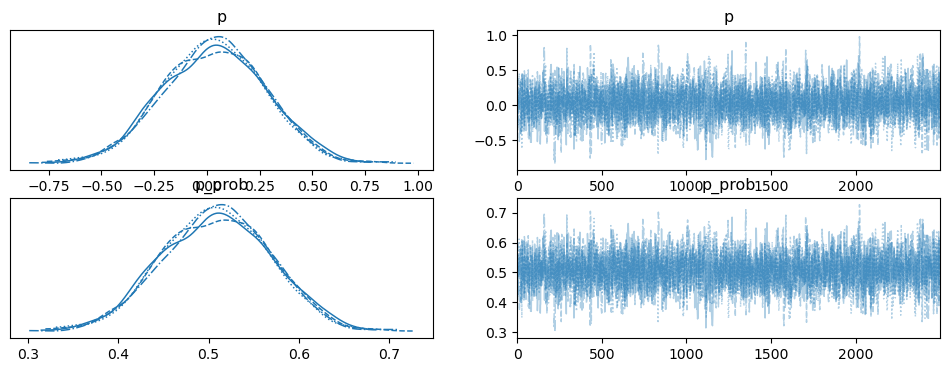

In [56]:
az.plot_trace(trace_berlin_emp)

array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>],
       [<Axes: title={'center': 'p_prob'}>,
        <Axes: title={'center': 'p_prob'}>]], dtype=object)

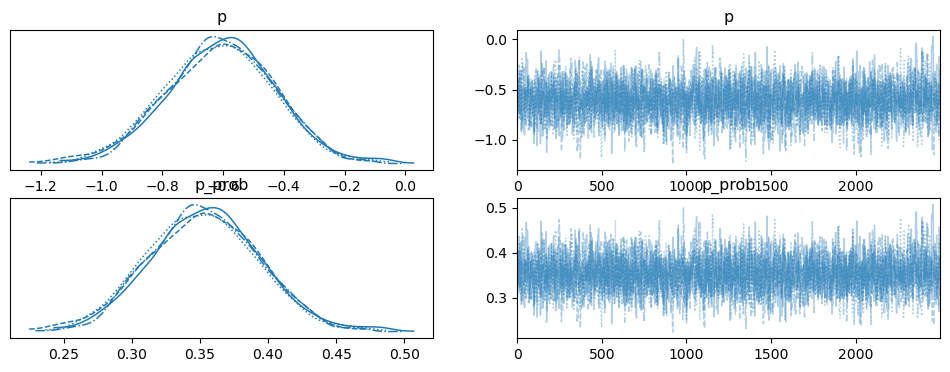

In [57]:
az.plot_trace(trace_vanuatu_emp)

## Plot results

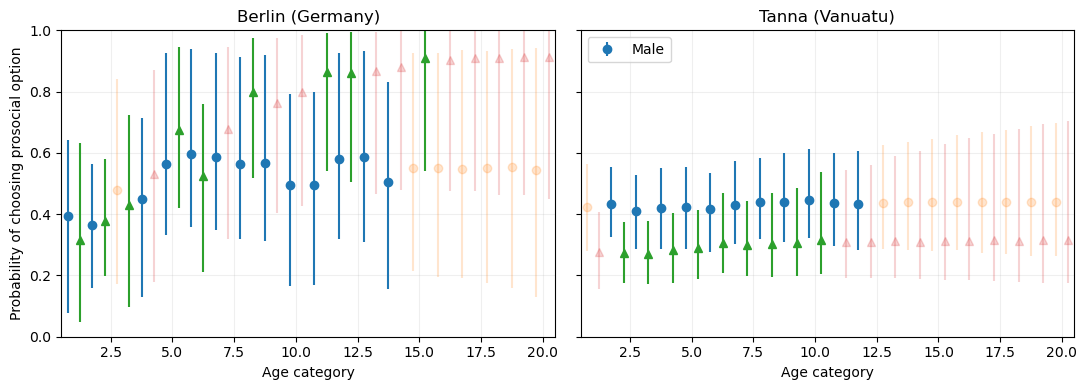

In [58]:
fig1 = plot_age_curves_pymc(trace_berlin, trace_vanuatu, d_list_berlin, d_list_vanuatu, outdir=None)

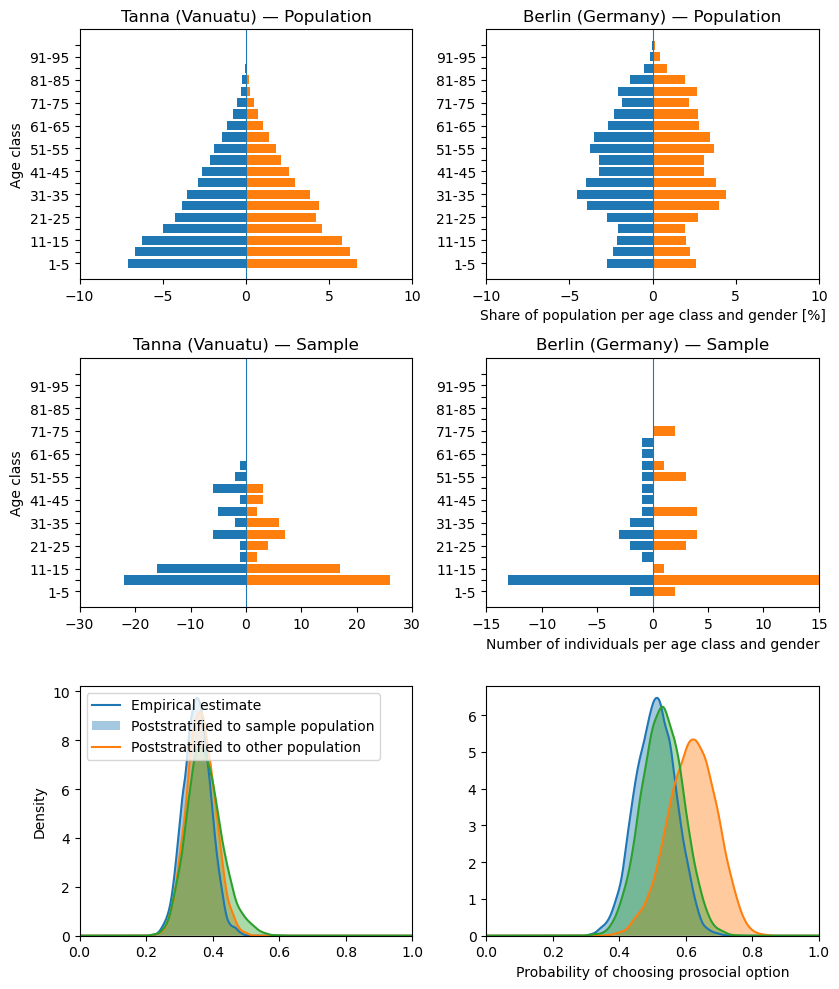

In [59]:
fig2 = plot_demographic_standardization_pymc(
    pop_vanuatu_perc=pop_van_perc, pop_berlin_perc=pop_ber_perc,
    sample_vanuatu_counts=sample_vanuatu, sample_berlin_counts=sample_berlin,
    idata_vanuatu=trace_vanuatu, idata_berlin=trace_berlin,
    idata_vanuatu_emp=trace_vanuatu_emp, idata_berlin_emp=trace_berlin_emp,
    outdir=None)